In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

In [2]:
df = pd.read_csv("Cleaned_Sales_Dataset.csv")
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Calculated_Sales,Difference,Month,Quarter,Year,Age_Group
0,ORD100002,2025-02-25 00:00:00,CUST5529,Customer_227,30,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,19808.39,0,February,1,2025,Young Adult
1,ORD100003,2025-10-14 00:00:00,CUST3127,Customer_182,63,Male,Bengaluru,Book,Education,5,27906.16,139530.80,139530.80,0,October,4,2025,Senior
2,ORD100004,2025-05-13 00:00:00,CUST8887,Customer_487,62,Female,Bengaluru,Book,Education,8,37491.06,299928.48,299928.48,0,May,2,2025,Senior
3,ORD100005,2025-12-02 00:00:00,CUST2515,Customer_470,65,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,256872.24,0,December,4,2025,Senior
4,ORD100006,2025-11-20 00:00:00,CUST4796,Customer_380,44,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,140365.90,0,November,4,2025,Adult


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          1000 non-null   object 
 1   Order_Date        1000 non-null   object 
 2   Customer_ID       1000 non-null   object 
 3   Customer_Name     1000 non-null   object 
 4   Age               1000 non-null   int64  
 5   Gender            1000 non-null   object 
 6   City              1000 non-null   object 
 7   Product           1000 non-null   object 
 8   Category          1000 non-null   object 
 9   Quantity          1000 non-null   int64  
 10  Unit_Price        1000 non-null   float64
 11  Total_Sales       1000 non-null   float64
 12  Calculated_Sales  1000 non-null   float64
 13  Difference        1000 non-null   int64  
 14  Month             1000 non-null   object 
 15  Quarter           1000 non-null   int64  
 16  Year              1000 non-null   int64  
 

,Age,Quantity,Unit_Price,Total_Sales,Calculated_Sales,Difference,Quarter,Year
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0,1000.000000,1000.000000
mean,41.353000,5.435000,25486.783410,139399.439650,139399.439650,0.0,2.499000,2025.005000
std,13.683626,2.838632,14179.402361,114100.051546,114100.051546,0.0,1.131937,0.070569
min,18.000000,1.000000,145.780000,437.340000,437.340000,0.0,1.000000,2025.000000
25%,30.000000,3.000000,13895.722500,47066.632500,47066.632500,0.0,1.000000,2025.000000
50%,41.000000,5.000000,25398.740000,108594.025000,108594.025000,0.0,2.000000,2025.000000
75%,53.000000,8.000000,37512.382500,203722.882500,203722.882500,0.0,4.000000,2025.000000
max,65.000000,10.000000,49997.530000,493677.500000,493677.500000,0.0,4.000000,2026.000000


In [16]:
def customer_segment(sales):
    if sales >= 200000:
        return "Premium"
    elif sales >= 100000:
        return "High Value"
    elif sales >= 50000:
        return "Medium Value"
    else:
        return "Low Value"

df["Customer_Segment"] = df["Total_Sales"].apply(customer_segment)

In [17]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Calculated_Sales,Difference,Month,Quarter,Year,Age_Group,Customer_Segment
0,ORD100002,2025-02-25 00:00:00,CUST5529,Customer_227,30,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,19808.39,0,February,1,2025,Young Adult,Low Value
1,ORD100003,2025-10-14 00:00:00,CUST3127,Customer_182,63,Male,Bengaluru,Book,Education,5,27906.16,139530.80,139530.80,0,October,4,2025,Senior,High Value
2,ORD100004,2025-05-13 00:00:00,CUST8887,Customer_487,62,Female,Bengaluru,Book,Education,8,37491.06,299928.48,299928.48,0,May,2,2025,Senior,Premium
3,ORD100005,2025-12-02 00:00:00,CUST2515,Customer_470,65,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,256872.24,0,December,4,2025,Senior,Premium
4,ORD100006,2025-11-20 00:00:00,CUST4796,Customer_380,44,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,140365.90,0,November,4,2025,Adult,High Value


In [18]:
#How many customers belong to each segment?

segment_count = df["Customer_Segment"].value_counts()
segment_count

Customer_Segment
High Value      277
Low Value       273
Premium         261
Medium Value    189
Name: count, dtype: int64

C:\Users\ritik\AppData\Local\Temp\ipykernel_18268\3891091252.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


<Axes: xlabel='Customer_Segment', ylabel='count'>

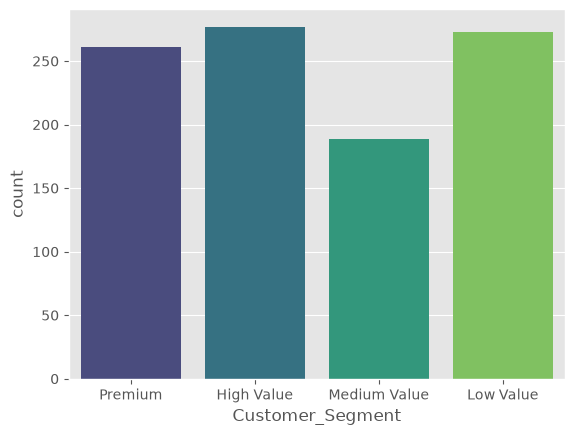

In [24]:
sns.countplot(
    data = df,
    x="Customer_Segment",
    order=["Premium","High Value","Medium Value","Low Value"],
    palette="viridis"
)

In [26]:
#Which segment contributes maximum revenue?

segment_revenue = (
    df.groupby("Customer_Segment")["Total_Sales"].sum().sort_values(ascending = False)
)
segment_revenue

Customer_Segment
Premium         78436938.04
High Value      39647093.08
Medium Value    14519528.23
Low Value        6795880.30
Name: Total_Sales, dtype: float64

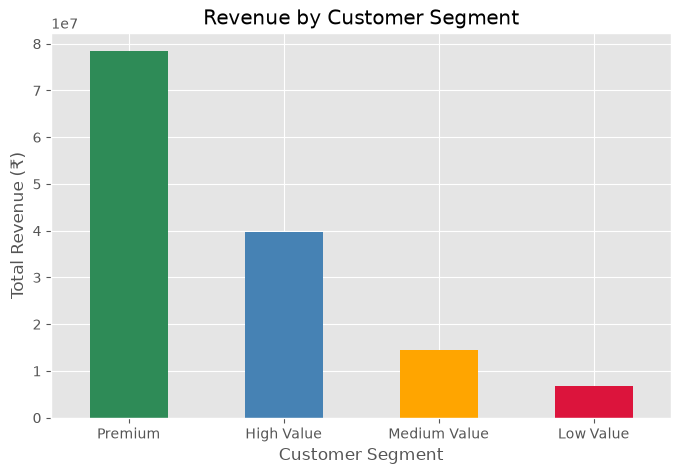

In [33]:
plt.figure(figsize=(8,5))

segment_revenue.plot(
    kind = 'bar',
     color=['#2E8B57','#4682B4','#FFA500','#DC143C']
)
plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue (₹)")
plt.xticks(rotation=0)

plt.show()

In [30]:
#Average Order Value (AOV)
#Which customer segment spends the most per order?

segment_aov = (
    df.groupby("Customer_Segment")["Total_Sales"].mean().round(2).sort_values(ascending = False)
)
print(segment_aov)

Customer_Segment
Premium         300524.67
High Value      143130.30
Medium Value     76822.90
Low Value        24893.33
Name: Total_Sales, dtype: float64


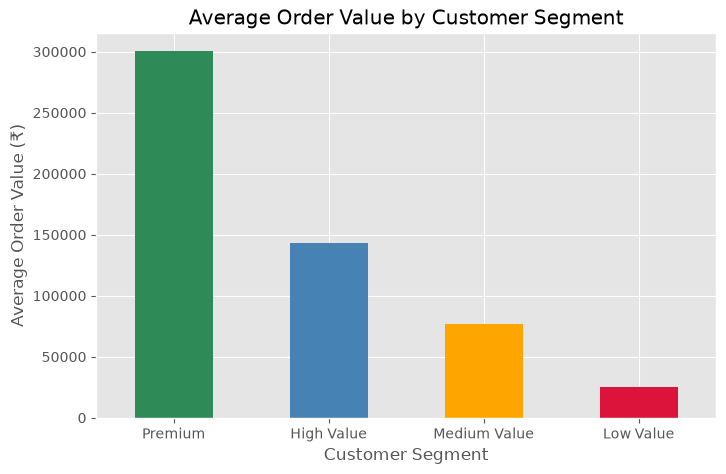

In [32]:
plt.figure(figsize=(8,5))

segment_aov.plot(
    kind='bar',
    color=['#2E8B57','#4682B4','#FFA500','#DC143C']
)

plt.title("Average Order Value by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Order Value (₹)")
plt.xticks(rotation=0)

plt.show()

In [35]:
#Average Quantity Purchased
#Which customer segment purchases more products?

segment_qty = (
    df.groupby("Customer_Segment")["Quantity"].mean().round(2).sort_values(ascending = False)
)

print(segment_qty)

Customer_Segment
Premium         8.03
High Value      5.80
Medium Value    4.51
Low Value       3.22
Name: Quantity, dtype: float64


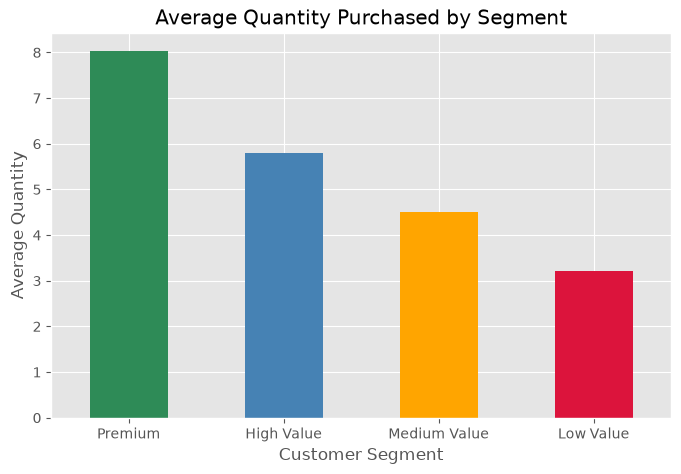

In [36]:
plt.figure(figsize=(8,5))

segment_qty.plot(
    kind='bar',
    color=['#2E8B57','#4682B4','#FFA500','#DC143C']
)

plt.title("Average Quantity Purchased by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Quantity")
plt.xticks(rotation=0)

plt.show()

In [37]:
#Age Group vs Customer Segment
#Which age group has the highest number of Premium, High Value, Medium Value, and Low Value customers?
age_segment = pd.crosstab(
    df["Age_Group"],
    df["Customer_Segment"]
)

print(age_segment)

Customer_Segment  High Value  Low Value  Medium Value  Premium
Age_Group                                                     
Adult                     92         90            64       86
Middle Age                89         86            42       78
Senior                    27         29            19       30
Young Adult               69         68            64       67


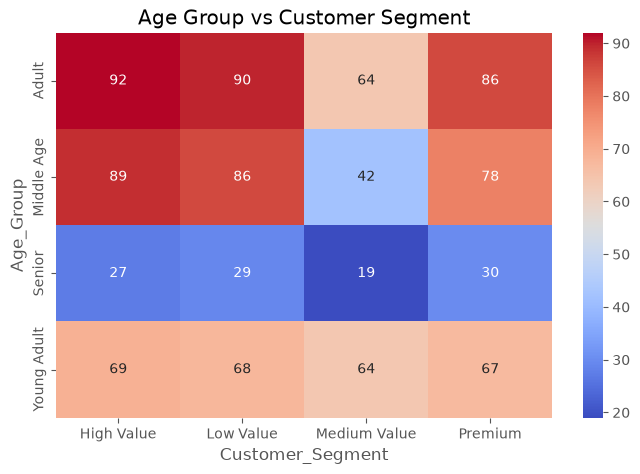

In [38]:
plt.figure(figsize=(8,5))

sns.heatmap(
    age_segment,
    annot = True,
    cmap = "coolwarm",
    fmt = "d"
)
plt.title("Age Group vs Customer Segment")
plt.show()

In [39]:
#Gender vs Customer Segment
#How are customer segments distributed across gender?

gender_segment = pd.crosstab(
    df["Gender"],
    df["Customer_Segment"]
)

print(gender_segment)

Customer_Segment  High Value  Low Value  Medium Value  Premium
Gender                                                        
Female                   147        136            87      119
Male                     130        137           102      142


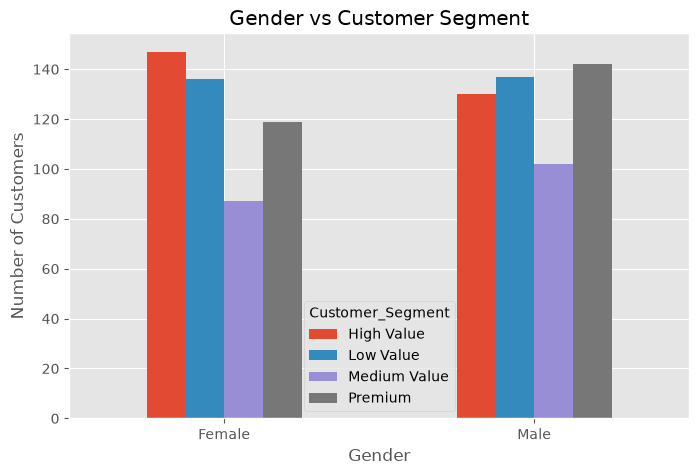

In [41]:
gender_segment.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Gender vs Customer Segment")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

In [42]:
#City vs Customer Segment
#Which cities have the highest number of Premium customers?

city_segment = pd.crosstab(
    df["City"],
    df["Customer_Segment"]
)
print(city_segment)

Customer_Segment  High Value  Low Value  Medium Value  Premium
City                                                          
Bengaluru                 30         30            25       37
Delhi                     36         40            19       30
Gaya                      31         36            26       24
Hyderabad                 37         38            21       29
Kolkata                   37         32            28       36
Mumbai                    38         33            21       39
Patna                     41         39            30       38
Pune                      27         25            19       28


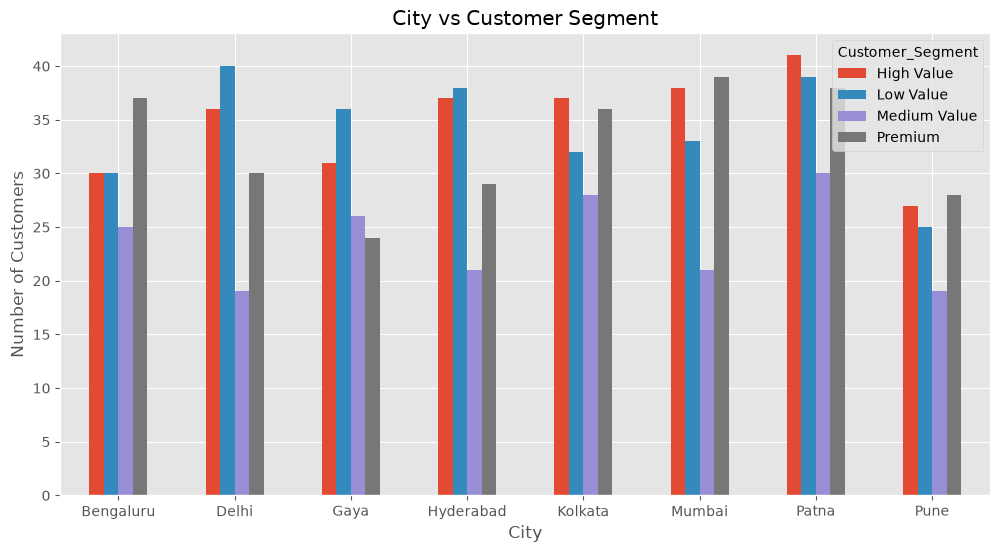

In [46]:
city_segment.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("City vs Customer Segment")
plt.xlabel("City")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)
plt.show()

In [47]:
#Category vs Customer Segment
#Which product categories are preferred by different customer segments?

category_segment = pd.crosstab(
    df["Category"],
    df["Customer_Segment"]
)
print(category_segment)

Customer_Segment  High Value  Low Value  Medium Value  Premium
Category                                                      
Education                 54         48            32       44
Electronics              107         96            58       93
Fashion                   44         45            32       35
Furniture                 38         45            35       41
Grocery                   34         39            32       48


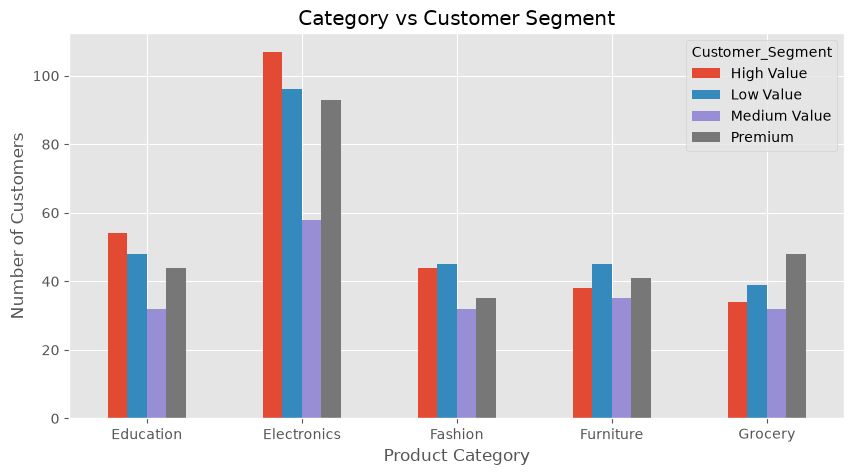

In [48]:
category_segment.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Category vs Customer Segment")
plt.xlabel("Product Category")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.show()

In [49]:
#Top 10 Customers by Revenue
#Who are the highest revenue-generating customers?

top_customers = (
    df.groupby(["Customer_ID", "Customer_Name"])["Total_Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_customers)

Customer_ID  Customer_Name
CUST2062     Customer_254     493677.5
CUST4706     Customer_200     492174.1
CUST1711     Customer_36      490866.4
CUST4869     Customer_392     485667.8
CUST7416     Customer_191     482551.9
CUST9551     Customer_230     474935.9
CUST8381     Customer_112     473144.2
CUST4037     Customer_205     470798.6
CUST4003     Customer_305     468522.0
CUST4584     Customer_138     462701.3
Name: Total_Sales, dtype: float64


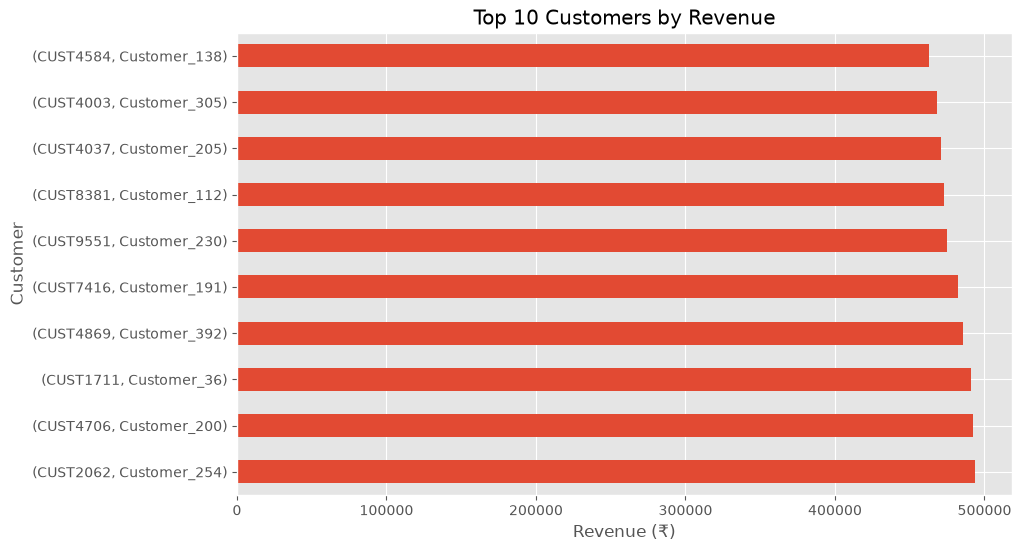

In [51]:
plt.figure(figsize=(10,6))

top_customers.plot(kind='barh')

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue (₹)")
plt.ylabel("Customer")

plt.show()

In [52]:
#Customer Segment Summary
#What is the overall performance of each customer segment?

segment_summary = (
    df.groupby("Customer_Segment")
      .agg(
          Total_Customers=("Customer_ID", "count"),
          Total_Revenue=("Total_Sales", "sum"),
          Average_Order_Value=("Total_Sales", "mean"),
          Average_Quantity=("Quantity", "mean")
      )
      .round(2)
)

segment_summary

,Total_Customers,Total_Revenue,Average_Order_Value,Average_Quantity
Customer_Segment,,,,
High Value,277,39647093.08,143130.30,5.80
Low Value,273,6795880.30,24893.33,3.22
Medium Value,189,14519528.23,76822.90,4.51
Premium,261,78436938.04,300524.67,8.03


In [4]:
df.to_csv("Cleaned_Sales_Dataset_With_Segments.csv", index=False)

In [5]:
import os 
print(os.getcwd())

C:\Users\ritik\OneDrive\Desktop\Apex Planet\Task3
